In [1]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm

print("\nReportLab OK")

Python do notebook:
C:\Users\beelt\Documents\collections_case_candidate\.venv\Scripts\python.exe

ReportLab OK


In [2]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")

1. Configuração
Por padrão, o gerador procura os notebooks na mesma pasta deste arquivo ou na pasta anterior.
Ajuste apenas os caminhos se a estrutura do repositório mudar.

In [3]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())

Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


## _______________________________________________________________ "" ____________________________________________________________

## _______________________________________________________________ "" ____________________________________________________________

CONTACT PRESSURE — MAXIMUM ATTEMPTS IN ANY 60-DAY WINDOW
Customers analysed : 11,724
Maximum observed   : 21

DISTRIBUTION
count   11,724.00
mean         6.43
std          3.75
min          1.00
50%          6.00
75%          9.00
80%         10.00
90%         12.00
95%         13.00
97%         14.00
99%         15.00
max         21.00
Name: max_contacts_60d, dtype: float64

CUSTOMERS EXPOSED TO HIGH CONTACT PRESSURE


,threshold,customers,pct_customers
0,5+ contacts / 60d,"7,573",64.6%
1,8+ contacts / 60d,"4,563",38.9%
2,10+ contacts / 60d,"2,649",22.6%
3,12+ contacts / 60d,"1,212",10.3%
4,15+ contacts / 60d,207,1.8%
5,18+ contacts / 60d,21,0.2%



CONTACT PRESSURE BANDS


,contact_pressure_band,customers,avg_max_contacts,max_contacts,pct_customers
0,1–5,"5,146",2.9,5,43.9%
1,6–8,"3,013",7.0,8,25.7%
2,9–12,"2,856",10.2,12,24.4%
3,13–15,617,13.7,15,5.3%
4,16+,92,16.8,21,0.8%


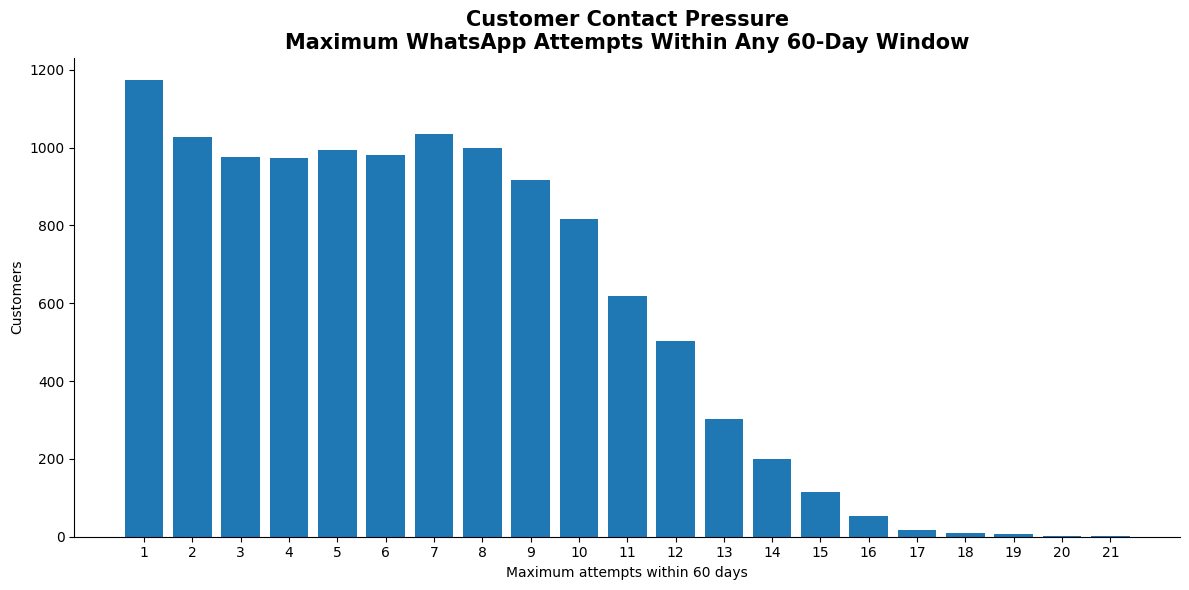

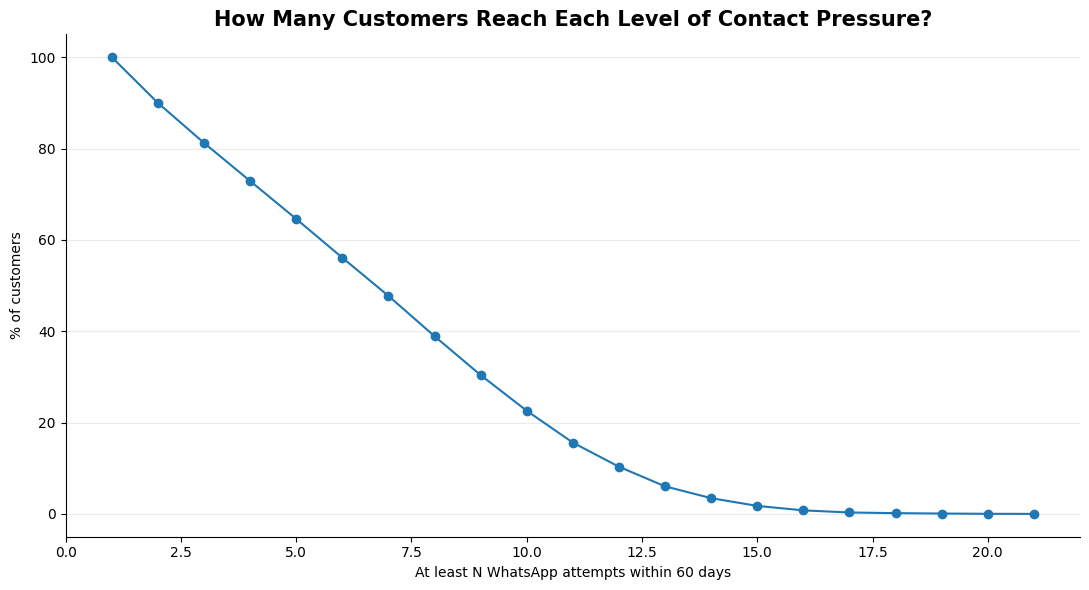


HIGHEST CONTACT PRESSURE CUSTOMERS


,customer_id,max_contacts_60d,window_start,window_end,total_messages,contact_pressure_band
6491,C006634,21,2026-06-14 11:21:00,2026-08-07 11:46:00,21,16+
5791,C005915,21,2026-06-11 10:52:00,2026-08-05 09:08:00,21,16+
4046,C004130,20,2026-06-12 11:26:00,2026-08-07 13:31:00,20,16+
4498,C004589,20,2026-06-11 11:04:00,2026-08-05 20:03:00,20,16+
4157,C004243,19,2026-06-03 11:46:00,2026-07-28 11:33:00,19,16+
2209,C002259,19,2026-06-20 14:31:00,2026-08-16 15:54:00,19,16+
1997,C002043,19,2026-07-02 20:13:00,2026-08-27 09:02:00,19,16+
8443,C008640,19,2026-06-25 18:51:00,2026-08-21 10:23:00,19,16+
7691,C007870,19,2026-06-15 15:49:00,2026-07-28 15:48:00,19,16+
9767,C009999,19,2026-06-13 12:58:00,2026-08-10 20:24:00,19,16+


In [5]:
# ============================================================
# CONTACT PRESSURE / COMPLIANCE RISK
# Maximum WhatsApp attempts in any rolling 60-day window
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = wa.copy()

# ------------------------------------------------------------
# 1. BASIC PREPARATION
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df
    .dropna(subset=["customer_id", "sent_at"])
    .sort_values(["customer_id", "sent_at"])
    .copy()
)

# ------------------------------------------------------------
# 2. MAXIMUM CONTACTS IN ANY 60-DAY WINDOW
# ------------------------------------------------------------

records = []

for customer_id, g in df.groupby("customer_id", sort=False):

    dates = g["sent_at"].sort_values().reset_index(drop=True)

    left = 0
    max_contacts_60d = 0
    max_window_start = None
    max_window_end = None

    for right in range(len(dates)):

        # Rolling window: current timestamp - 60 days
        while dates.iloc[right] - dates.iloc[left] > pd.Timedelta(days=60):
            left += 1

        n_contacts = right - left + 1

        if n_contacts > max_contacts_60d:
            max_contacts_60d = n_contacts
            max_window_start = dates.iloc[left]
            max_window_end = dates.iloc[right]

    records.append({
        "customer_id": customer_id,
        "max_contacts_60d": max_contacts_60d,
        "window_start": max_window_start,
        "window_end": max_window_end,
        "total_messages": len(g),
    })

pressure = pd.DataFrame(records)

# ------------------------------------------------------------
# 3. DISTRIBUTION
# ------------------------------------------------------------

print("=" * 75)
print("CONTACT PRESSURE — MAXIMUM ATTEMPTS IN ANY 60-DAY WINDOW")
print("=" * 75)

print(f"Customers analysed : {pressure['customer_id'].nunique():,}")
print(f"Maximum observed   : {pressure['max_contacts_60d'].max():,}")
print()

print("DISTRIBUTION")
print(
    pressure["max_contacts_60d"]
    .describe(percentiles=[.50, .75, .80, .90, .95, .97, .99])
    .round(2)
)

# ------------------------------------------------------------
# 4. THRESHOLD ANALYSIS
# ------------------------------------------------------------

thresholds = [5, 8, 10, 12, 15, 18]

rows = []

N = pressure["customer_id"].nunique()

for t in thresholds:

    affected = pressure["max_contacts_60d"] >= t

    rows.append({
        "threshold": f"{t}+ contacts / 60d",
        "customers": affected.sum(),
        "pct_customers": affected.mean() * 100,
    })

threshold_table = pd.DataFrame(rows)

print()
print("=" * 75)
print("CUSTOMERS EXPOSED TO HIGH CONTACT PRESSURE")
print("=" * 75)

display(
    threshold_table.style.format({
        "customers": "{:,.0f}",
        "pct_customers": "{:.1f}%"
    })
)

# ------------------------------------------------------------
# 5. CONTACT PRESSURE BANDS
# ------------------------------------------------------------

pressure["contact_pressure_band"] = pd.cut(
    pressure["max_contacts_60d"],
    bins=[0, 5, 8, 12, 15, np.inf],
    labels=[
        "1–5",
        "6–8",
        "9–12",
        "13–15",
        "16+"
    ],
    right=True
)

band_table = (
    pressure
    .groupby("contact_pressure_band", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        avg_max_contacts=("max_contacts_60d", "mean"),
        max_contacts=("max_contacts_60d", "max")
    )
    .reset_index()
)

band_table["pct_customers"] = (
    band_table["customers"] /
    pressure["customer_id"].nunique() * 100
)

print()
print("=" * 75)
print("CONTACT PRESSURE BANDS")
print("=" * 75)

display(
    band_table.style.format({
        "customers": "{:,.0f}",
        "pct_customers": "{:.1f}%",
        "avg_max_contacts": "{:.1f}",
        "max_contacts": "{:.0f}"
    })
)

# ------------------------------------------------------------
# 6. DISTRIBUTION CHART
# ------------------------------------------------------------

dist = (
    pressure["max_contacts_60d"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    dist.index.astype(str),
    dist.values
)

ax.set_title(
    "Customer Contact Pressure\n"
    "Maximum WhatsApp Attempts Within Any 60-Day Window",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Maximum attempts within 60 days")
ax.set_ylabel("Customers")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. CUMULATIVE EXPOSURE CHART
# ------------------------------------------------------------

max_n = int(pressure["max_contacts_60d"].max())

exposure = []

for n in range(1, max_n + 1):

    customers = (
        pressure["max_contacts_60d"] >= n
    ).sum()

    exposure.append({
        "contacts_60d": n,
        "customers": customers,
        "pct_customers": customers / N * 100
    })

exposure = pd.DataFrame(exposure)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    exposure["contacts_60d"],
    exposure["pct_customers"],
    marker="o"
)

ax.set_title(
    "How Many Customers Reach Each Level of Contact Pressure?",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("At least N WhatsApp attempts within 60 days")
ax.set_ylabel("% of customers")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. MOST EXPOSED CUSTOMERS
# ------------------------------------------------------------

top_pressure = (
    pressure
    .sort_values(
        "max_contacts_60d",
        ascending=False
    )
    .head(30)
)

print()
print("=" * 75)
print("HIGHEST CONTACT PRESSURE CUSTOMERS")
print("=" * 75)

display(top_pressure)

MARGINAL PERFORMANCE BY CONTACT NUMBER


,contact_band,messages,customers,payment_events,recovery_brl,engagements,clicks,replies,no_prior_positive_messages,payment_rate,engagement_rate,recovery_per_message,share_no_prior_positive
0,1–5,"47,919","11,724","4,112","R$ 2,551,718.94","15,840",0,"3,244","25,898",8.58%,33.06%,R$ 53.25,54.0%
1,6–8,"16,739","6,578",967,"R$ 597,319.79","4,036",0,841,"2,864",5.78%,24.11%,R$ 35.68,17.1%
2,9–10,"6,214","3,565",346,"R$ 194,754.08","1,341",0,305,868,5.57%,21.58%,R$ 31.34,14.0%
3,11–12,"3,044","1,832",153,"R$ 83,471.73",599,0,112,389,5.03%,19.68%,R$ 27.42,12.8%
4,13–15,"1,322",709,43,"R$ 27,727.59",220,0,46,182,3.25%,16.64%,R$ 20.97,13.8%
5,16+,168,92,5,"R$ 4,313.17",24,0,7,23,2.98%,14.29%,R$ 25.67,13.7%



CONTACTS WITH NO PRIOR POSITIVE SIGNAL


,contact_band,messages,customers,payment_events,recovery_brl,engagements,clicks,replies,payment_rate,engagement_rate,recovery_per_message
0,1–5,"25,898","11,724","2,155","R$ 1,443,429.95","8,428",0,"1,713",8.32%,32.54%,R$ 55.74
1,6–8,"2,864","1,241",63,"R$ 43,619.22",307,0,66,2.20%,10.72%,R$ 15.23
2,9–10,868,514,16,"R$ 9,930.73",51,0,13,1.84%,5.88%,R$ 11.44
3,11–12,389,229,2,"R$ 1,578.72",9,0,0,0.51%,2.31%,R$ 4.06
4,13–15,182,96,0,R$ 0.00,2,0,1,0.00%,1.10%,R$ 0.00
5,16+,23,17,0,R$ 0.00,0,0,0,0.00%,0.00%,R$ 0.00



PERFORMANCE BY EXACT CONTACT NUMBER


,contact_number,messages,customers,payment_events,recovery_brl,engagements,payment_rate,engagement_rate,recovery_per_message
0,1,"11,724","11,724","1,155","R$ 762,592.41","4,495",9.85%,38.34%,R$ 65.05
1,2,"10,551","10,551",959,"R$ 600,847.22","3,796",9.09%,35.98%,R$ 56.95
2,3,"9,524","9,524",814,"R$ 483,080.58","3,078",8.55%,32.32%,R$ 50.72
3,4,"8,547","8,547",664,"R$ 397,653.72","2,488",7.77%,29.11%,R$ 46.53
4,5,"7,573","7,573",520,"R$ 307,545.01","1,983",6.87%,26.19%,R$ 40.61
5,6,"6,578","6,578",396,"R$ 240,597.24","1,628",6.02%,24.75%,R$ 36.58
6,7,"5,598","5,598",340,"R$ 213,088.08","1,387",6.07%,24.78%,R$ 38.07
7,8,"4,563","4,563",231,"R$ 143,634.47","1,021",5.06%,22.38%,R$ 31.48
8,9,"3,565","3,565",206,"R$ 119,163.91",800,5.78%,22.44%,R$ 33.43
9,10,"2,649","2,649",140,"R$ 75,590.17",541,5.29%,20.42%,R$ 28.54


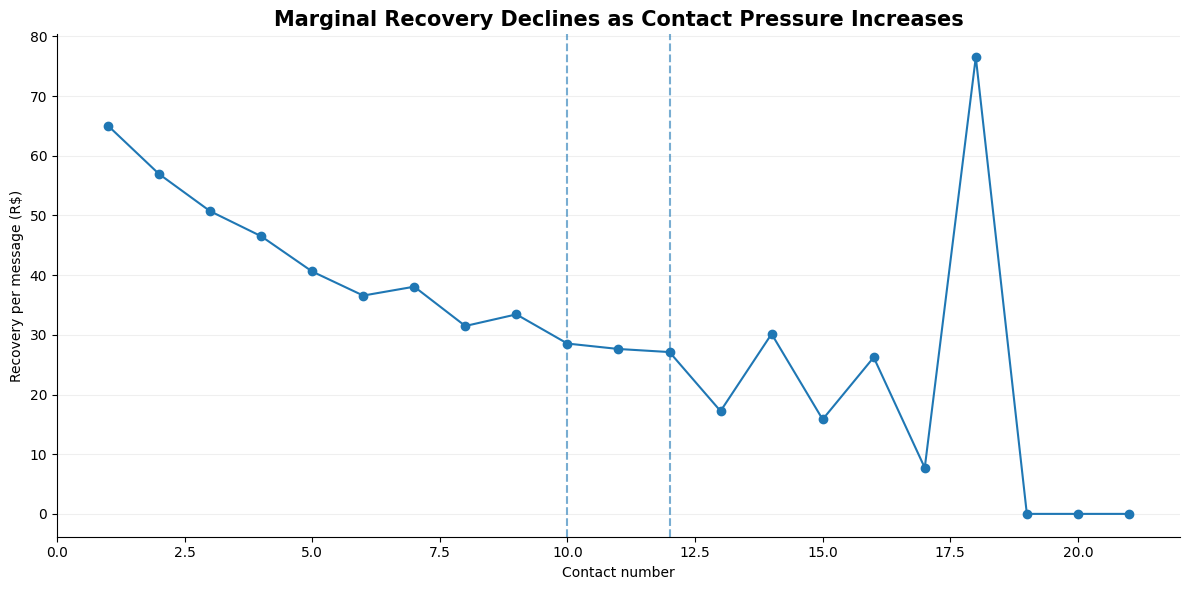

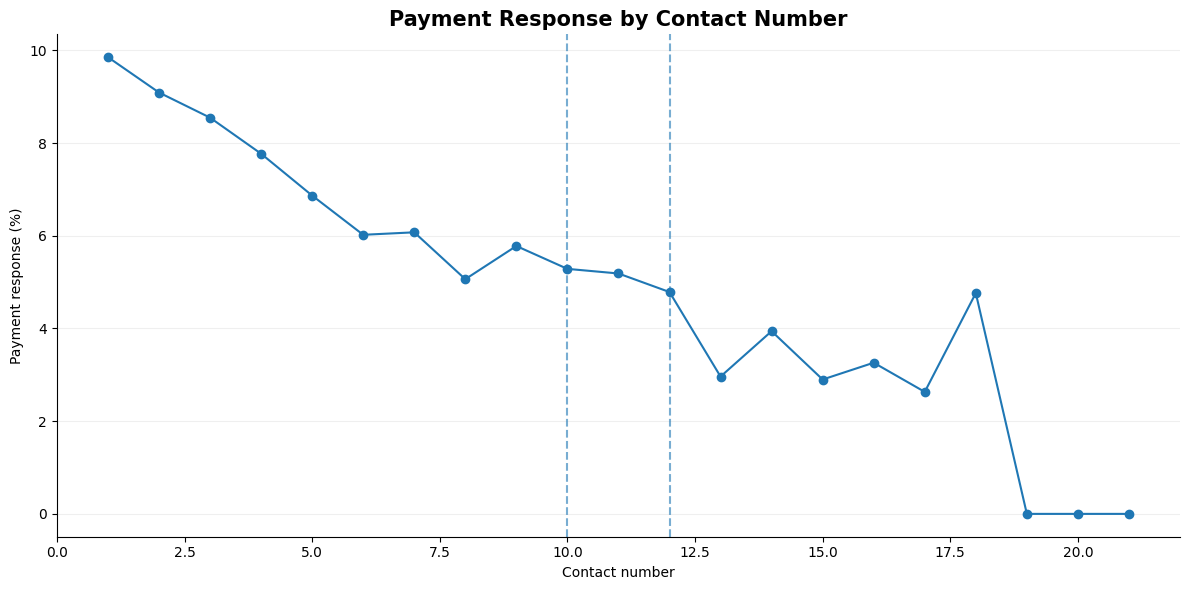

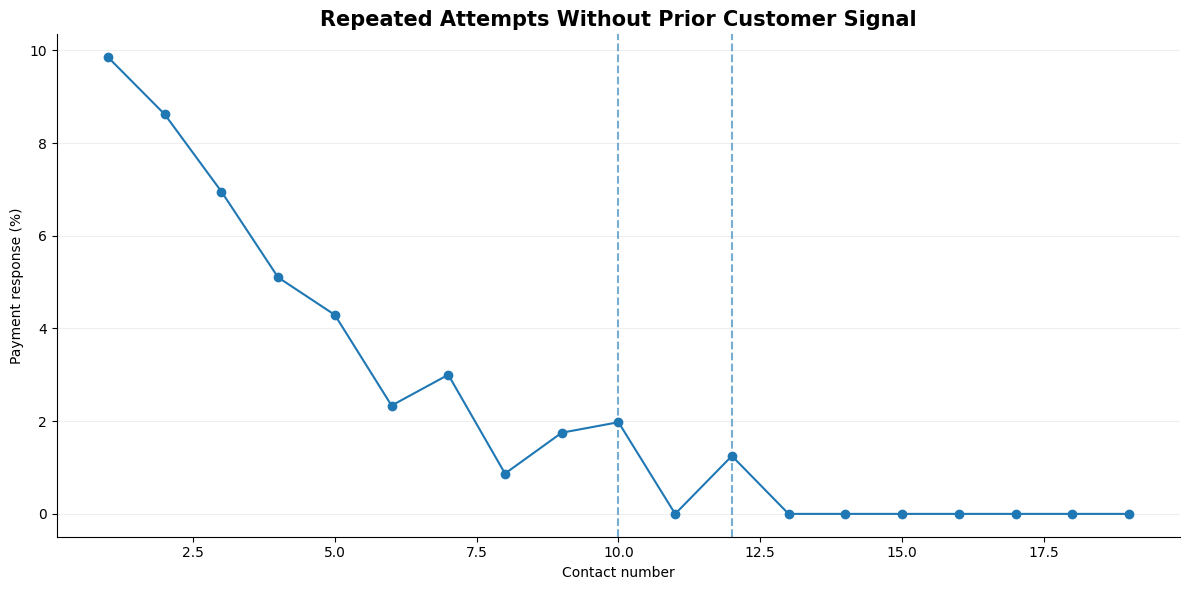


POTENTIAL CONTACT-PRESSURE REVIEW TRIGGERS


,review_after_contact,messages_above_threshold,customers_above_threshold,recovery_above_threshold,payment_events_above_threshold,messages_no_prior_signal,customers_no_prior_signal,recovery_no_prior_signal,payment_events_no_prior_signal,recovery_per_cold_message
0,5,"27,487","6,578","R$ 907,586.36","1,514","4,326","1,241","R$ 55,128.67",81,R$ 12.74
1,8,"10,748","3,565","R$ 310,266.57",547,"1,462",514,"R$ 11,509.45",18,R$ 7.87
2,10,"4,534","1,832","R$ 115,512.49",201,594,229,"R$ 1,578.72",2,R$ 2.66
3,12,"1,490",709,"R$ 32,040.76",48,205,96,R$ 0.00,0,R$ 0.00
4,15,168,92,"R$ 4,313.17",5,23,17,R$ 0.00,0,R$ 0.00


In [6]:
# ============================================================
# CONTACT PRESSURE — MARGINAL VALUE OF ADDITIONAL ATTEMPTS
#
# Goal:
# Understand what happens as collection attempts accumulate.
#
# IMPORTANT:
# Descriptive analysis, NOT causal.
# High contact counts are endogenous:
# difficult-to-collect customers naturally accumulate attempts.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = wa.copy()

# ------------------------------------------------------------
# 1. PREPARATION
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

df = (
    df
    .dropna(subset=["customer_id", "sent_at"])
    .sort_values(["customer_id", "sent_at", "message_id"])
    .copy()
)

# Sequential attempt number across observed history
df["contact_number"] = (
    df.groupby("customer_id").cumcount() + 1
)

# ------------------------------------------------------------
# 2. BASIC OUTCOME FLAGS
# ------------------------------------------------------------

df["payment_flag"] = (
    pd.to_numeric(df["amount_paid_brl"], errors="coerce")
    .fillna(0)
    .gt(0)
)

df["recovery_brl"] = (
    pd.to_numeric(df["amount_paid_brl"], errors="coerce")
    .fillna(0)
)

# Engagement:
# read / clicked / replied
df["engagement_flag"] = (
    df["interaction"]
    .astype(str)
    .str.lower()
    .isin(["read", "clicked", "replied"])
)

df["click_flag"] = (
    df["interaction"]
    .astype(str)
    .str.lower()
    .eq("clicked")
)

df["reply_flag"] = (
    df["interaction"]
    .astype(str)
    .str.lower()
    .eq("replied")
)

# ------------------------------------------------------------
# 3. PRIOR POSITIVE SIGNALS
#
# Strict point-in-time:
# only information BEFORE current contact.
# ------------------------------------------------------------

df["prior_payment"] = (
    df.groupby("customer_id")["payment_flag"]
      .transform(lambda x: x.shift(1).cummax())
      .fillna(False)
      .astype(bool)
)

df["prior_engagement"] = (
    df.groupby("customer_id")["engagement_flag"]
      .transform(lambda x: x.shift(1).cummax())
      .fillna(False)
      .astype(bool)
)

# Positive signal = engagement OR payment before current contact
df["prior_positive_signal"] = (
    df["prior_payment"] |
    df["prior_engagement"]
)

df["no_prior_positive_signal"] = ~df["prior_positive_signal"]


# ------------------------------------------------------------
# 4. CONTACT PRESSURE BANDS
# ------------------------------------------------------------

def contact_band(n):

    if n <= 5:
        return "1–5"

    elif n <= 8:
        return "6–8"

    elif n <= 10:
        return "9–10"

    elif n <= 12:
        return "11–12"

    elif n <= 15:
        return "13–15"

    else:
        return "16+"


df["contact_band"] = (
    df["contact_number"]
    .apply(contact_band)
)

band_order = [
    "1–5",
    "6–8",
    "9–10",
    "11–12",
    "13–15",
    "16+"
]

df["contact_band"] = pd.Categorical(
    df["contact_band"],
    categories=band_order,
    ordered=True
)


# ------------------------------------------------------------
# 5. OVERALL PERFORMANCE BY CONTACT BAND
# ------------------------------------------------------------

band_summary = (
    df
    .groupby("contact_band", observed=True)
    .agg(
        messages=("message_id", "count"),
        customers=("customer_id", "nunique"),

        payment_events=("payment_flag", "sum"),
        recovery_brl=("recovery_brl", "sum"),

        engagements=("engagement_flag", "sum"),
        clicks=("click_flag", "sum"),
        replies=("reply_flag", "sum"),

        no_prior_positive_messages=(
            "no_prior_positive_signal",
            "sum"
        )
    )
    .reset_index()
)

band_summary["payment_rate"] = (
    band_summary["payment_events"] /
    band_summary["messages"] * 100
)

band_summary["engagement_rate"] = (
    band_summary["engagements"] /
    band_summary["messages"] * 100
)

band_summary["recovery_per_message"] = (
    band_summary["recovery_brl"] /
    band_summary["messages"]
)

band_summary["share_no_prior_positive"] = (
    band_summary["no_prior_positive_messages"] /
    band_summary["messages"] * 100
)


print("=" * 100)
print("MARGINAL PERFORMANCE BY CONTACT NUMBER")
print("=" * 100)

display(
    band_summary.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "payment_events": "{:,.0f}",
        "recovery_brl": "R$ {:,.2f}",
        "engagements": "{:,.0f}",
        "clicks": "{:,.0f}",
        "replies": "{:,.0f}",
        "no_prior_positive_messages": "{:,.0f}",
        "payment_rate": "{:.2f}%",
        "engagement_rate": "{:.2f}%",
        "recovery_per_message": "R$ {:,.2f}",
        "share_no_prior_positive": "{:.1f}%"
    })
)


# ------------------------------------------------------------
# 6. SPECIFICALLY:
# CONTACTS SENT WITHOUT ANY PRIOR POSITIVE SIGNAL
# ------------------------------------------------------------

cold = df[df["no_prior_positive_signal"]].copy()

cold_summary = (
    cold
    .groupby("contact_band", observed=True)
    .agg(
        messages=("message_id", "count"),
        customers=("customer_id", "nunique"),

        payment_events=("payment_flag", "sum"),
        recovery_brl=("recovery_brl", "sum"),

        engagements=("engagement_flag", "sum"),
        clicks=("click_flag", "sum"),
        replies=("reply_flag", "sum")
    )
    .reset_index()
)

cold_summary["payment_rate"] = (
    cold_summary["payment_events"] /
    cold_summary["messages"] * 100
)

cold_summary["engagement_rate"] = (
    cold_summary["engagements"] /
    cold_summary["messages"] * 100
)

cold_summary["recovery_per_message"] = (
    cold_summary["recovery_brl"] /
    cold_summary["messages"]
)


print()
print("=" * 100)
print("CONTACTS WITH NO PRIOR POSITIVE SIGNAL")
print("=" * 100)

display(
    cold_summary.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "payment_events": "{:,.0f}",
        "recovery_brl": "R$ {:,.2f}",
        "engagements": "{:,.0f}",
        "clicks": "{:,.0f}",
        "replies": "{:,.0f}",
        "payment_rate": "{:.2f}%",
        "engagement_rate": "{:.2f}%",
        "recovery_per_message": "R$ {:,.2f}"
    })
)


# ------------------------------------------------------------
# 7. EXACT CONTACT NUMBER
#
# Lets us identify where performance deteriorates.
# ------------------------------------------------------------

exact_contact = (
    df
    .groupby("contact_number")
    .agg(
        messages=("message_id", "count"),
        customers=("customer_id", "nunique"),

        payment_events=("payment_flag", "sum"),
        recovery_brl=("recovery_brl", "sum"),

        engagements=("engagement_flag", "sum")
    )
    .reset_index()
)

exact_contact["payment_rate"] = (
    exact_contact["payment_events"] /
    exact_contact["messages"] * 100
)

exact_contact["engagement_rate"] = (
    exact_contact["engagements"] /
    exact_contact["messages"] * 100
)

exact_contact["recovery_per_message"] = (
    exact_contact["recovery_brl"] /
    exact_contact["messages"]
)


print()
print("=" * 100)
print("PERFORMANCE BY EXACT CONTACT NUMBER")
print("=" * 100)

display(
    exact_contact.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "payment_events": "{:,.0f}",
        "recovery_brl": "R$ {:,.2f}",
        "engagements": "{:,.0f}",
        "payment_rate": "{:.2f}%",
        "engagement_rate": "{:.2f}%",
        "recovery_per_message": "R$ {:,.2f}"
    })
)


# ------------------------------------------------------------
# 8. EXACT CONTACT NUMBER — NO PRIOR POSITIVE SIGNAL
# ------------------------------------------------------------

exact_cold = (
    cold
    .groupby("contact_number")
    .agg(
        messages=("message_id", "count"),
        customers=("customer_id", "nunique"),

        payment_events=("payment_flag", "sum"),
        recovery_brl=("recovery_brl", "sum"),

        engagements=("engagement_flag", "sum")
    )
    .reset_index()
)

exact_cold["payment_rate"] = (
    exact_cold["payment_events"] /
    exact_cold["messages"] * 100
)

exact_cold["engagement_rate"] = (
    exact_cold["engagements"] /
    exact_cold["messages"] * 100
)

exact_cold["recovery_per_message"] = (
    exact_cold["recovery_brl"] /
    exact_cold["messages"]
)


# ------------------------------------------------------------
# 9. CHART 1
# Recovery per message by attempt number
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    exact_contact["contact_number"],
    exact_contact["recovery_per_message"],
    marker="o"
)

ax.set_title(
    "Marginal Recovery Declines as Contact Pressure Increases",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Contact number")
ax.set_ylabel("Recovery per message (R$)")

ax.axvline(
    x=10,
    linestyle="--",
    alpha=0.6
)

ax.axvline(
    x=12,
    linestyle="--",
    alpha=0.6
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. CHART 2
# Payment response by attempt number
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    exact_contact["contact_number"],
    exact_contact["payment_rate"],
    marker="o"
)

ax.set_title(
    "Payment Response by Contact Number",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Contact number")
ax.set_ylabel("Payment response (%)")

ax.axvline(
    x=10,
    linestyle="--",
    alpha=0.6
)

ax.axvline(
    x=12,
    linestyle="--",
    alpha=0.6
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. CHART 3 — MOST IMPORTANT FOR THE SLIDE
#
# Payment response among customers who had NEVER shown
# a positive signal before that attempt.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    exact_cold["contact_number"],
    exact_cold["payment_rate"],
    marker="o"
)

ax.set_title(
    "Repeated Attempts Without Prior Customer Signal",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Contact number")
ax.set_ylabel("Payment response (%)")

ax.axvline(
    x=10,
    linestyle="--",
    alpha=0.6
)

ax.axvline(
    x=12,
    linestyle="--",
    alpha=0.6
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. POTENTIAL GUARDRAILS
#
# Descriptive simulation:
# what volume occurs ABOVE each possible threshold?
#
# NOT interpreted as "all these messages can be removed",
# because some later contacts generate recovery.
# ------------------------------------------------------------

guardrails = []

for threshold in [5, 8, 10, 12, 15]:

    above = df[
        df["contact_number"] > threshold
    ]

    cold_above = above[
        above["no_prior_positive_signal"]
    ]

    guardrails.append({

        "review_after_contact": threshold,

        "messages_above_threshold":
            len(above),

        "customers_above_threshold":
            above["customer_id"].nunique(),

        "recovery_above_threshold":
            above["recovery_brl"].sum(),

        "payment_events_above_threshold":
            above["payment_flag"].sum(),

        "messages_no_prior_signal":
            len(cold_above),

        "customers_no_prior_signal":
            cold_above["customer_id"].nunique(),

        "recovery_no_prior_signal":
            cold_above["recovery_brl"].sum(),

        "payment_events_no_prior_signal":
            cold_above["payment_flag"].sum()
    })


guardrail_table = pd.DataFrame(guardrails)

guardrail_table["recovery_per_cold_message"] = (
    guardrail_table["recovery_no_prior_signal"] /
    guardrail_table["messages_no_prior_signal"]
)


print()
print("=" * 100)
print("POTENTIAL CONTACT-PRESSURE REVIEW TRIGGERS")
print("=" * 100)

display(
    guardrail_table.style.format({

        "review_after_contact": "{:.0f}",

        "messages_above_threshold": "{:,.0f}",
        "customers_above_threshold": "{:,.0f}",

        "recovery_above_threshold": "R$ {:,.2f}",
        "payment_events_above_threshold": "{:,.0f}",

        "messages_no_prior_signal": "{:,.0f}",
        "customers_no_prior_signal": "{:,.0f}",

        "recovery_no_prior_signal": "R$ {:,.2f}",
        "payment_events_no_prior_signal": "{:,.0f}",

        "recovery_per_cold_message": "R$ {:,.2f}"
    })
)